# Generating our dataset

In [2]:
import numpy as np
import pandas as pd

Setting random seed for reproducibility

In [4]:
np.random.seed(42)

Setting a number of samples of 2000

In [6]:
n_samples = 2000
sampling_rate = 100  # Hz
duration = n_samples / sampling_rate  # in seconds
timestamps = np.linspace(0, duration, n_samples)

Sensor signal simulation :
- Noise : giving randomness to our input data
- Cumulative Drift : cumulating an error 

In [8]:
def generate_sensor_data(base_signal, noise_level=0.2, drift_factor=0.001, failure=False):
    noise = np.random.normal(0, noise_level, size=base_signal.shape)
    drift = np.cumsum(np.random.normal(0, drift_factor, size=base_signal.shape)) if failure else 0
    return base_signal + noise + drift

Simulating motion along x, y, z axes as simple sinusoidal functions with different frenquencies :

In [10]:
t = timestamps
base_ax = np.sin(2 * np.pi * 0.5 * t)
base_ay = np.cos(2 * np.pi * 0.5 * t)
base_az = 0.5 * np.sin(2 * np.pi * 0.2 * t)

Iniatializing our Dataset

In [12]:
data = []

- Generating normal and failure data (50/50).
- Supposing we only have two MPU6050, but we can integrate whatever number of them.

In [14]:
for i in range(n_samples):
    is_failure = 1 if i > n_samples // 2 else 0

    ax1 = generate_sensor_data(np.array([base_ax[i]]), failure=is_failure)[0]
    ay1 = generate_sensor_data(np.array([base_ay[i]]), failure=is_failure)[0]
    az1 = generate_sensor_data(np.array([base_az[i]]), failure=is_failure)[0]

    ax2 = generate_sensor_data(np.array([base_ax[i] * 0.8]), failure=is_failure)[0]
    ay2 = generate_sensor_data(np.array([base_ay[i] * 0.8]), failure=is_failure)[0]
    az2 = generate_sensor_data(np.array([base_az[i] * 0.8]), failure=is_failure)[0]

    temp = 25 + (np.random.normal(0, 0.3)) + (2 if is_failure else 0)  # slight increase in failure

    data.append([t[i], ax1, ay1, az1, ax2, ay2, az2, temp, is_failure])

Create DataFrame

In [16]:
df = pd.DataFrame(data, columns=[
    "timestamp", "ax1", "ay1", "az1", "ax2", "ay2", "az2", "temperature", "vibration"
])

### Visualizing our dataset

Import Libraries

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

Configure Plotting Style

In [21]:
sns.set(style="whitegrid")

In [22]:
df.sample(5)

,timestamp,ax1,ay1,az1,ax2,ay2,az2,temperature,vibration
70,0.700350,0.806775,-0.292686,0.400870,0.474439,-0.166315,0.416099,24.688826,0
864,8.644322,0.629959,-0.610236,-0.220161,0.923177,-0.423047,-0.225598,25.102365,0
280,2.801401,0.573241,-0.754485,-0.080656,0.596419,-0.538156,-0.129988,24.940798,0
267,2.671336,0.776436,-0.733790,-0.149808,0.625272,-0.254187,0.176603,25.418705,0
1874,18.749375,1.028757,-0.689445,-0.253753,0.732661,-0.544174,-0.365269,26.842639,1


Split Data into Normal and Failure

In [27]:
df_normal = df[df['vibration'] == 0]
df_failure = df[df['vibration'] == 1]

 Visualize Accelerations for Sensor 1

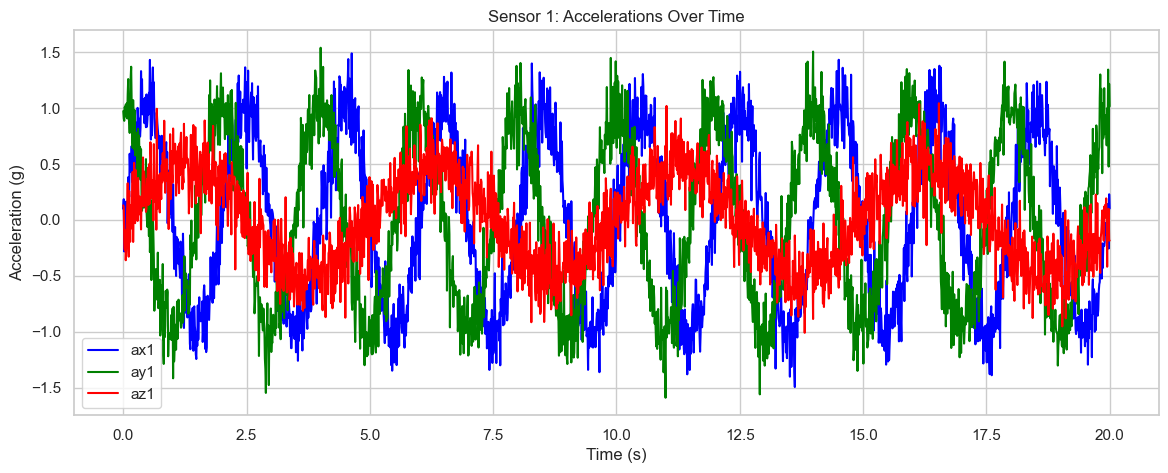

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['ax1'], label='ax1', color='blue')
plt.plot(df['timestamp'], df['ay1'], label='ay1', color='green')
plt.plot(df['timestamp'], df['az1'], label='az1', color='red')
plt.title('Sensor 1: Accelerations Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

Visualize Accelerations for Sensor 2

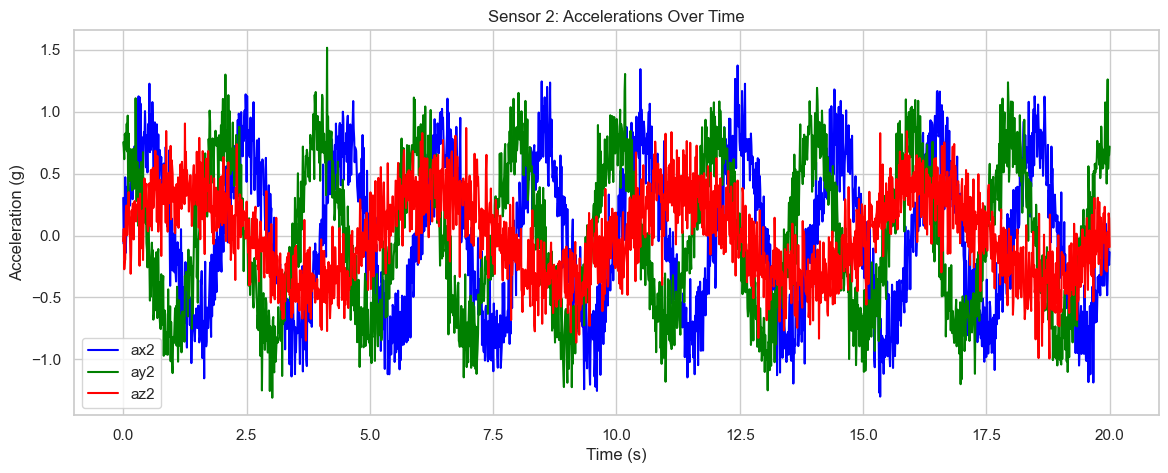

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['ax2'], label='ax2', color='blue')
plt.plot(df['timestamp'], df['ay2'], label='ay2', color='green')
plt.plot(df['timestamp'], df['az2'], label='az2', color='red')
plt.title('Sensor 2: Accelerations Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

To see whether our problem needs recursive data, we've tried to Predict vibration using recursive window logic

In [43]:
df[df['vibration']==1]

,timestamp,ax1,ay1,az1,ax2,ay2,az2,temperature,vibration
1001,10.015008,0.319167,1.287914,0.016739,0.183811,0.880041,-0.161953,27.016560,1
1002,10.025013,0.486614,0.885591,0.243589,0.123766,0.566466,-0.260782,27.150275,1
1003,10.035018,-0.085071,1.237171,-0.166765,-0.067921,0.712846,-0.286073,26.833467,1
1004,10.045023,0.143312,0.734551,0.222231,0.323111,0.818883,-0.031482,27.585932,1
1005,10.055028,0.310942,1.103891,0.058208,-0.050604,0.748528,-0.387304,26.718961,1
...,...,...,...,...,...,...,...,...,...
1995,19.959980,0.142394,0.830919,0.090416,-0.349736,1.261507,0.029779,27.146989,1
1996,19.969985,0.098157,1.343402,-0.071200,0.017896,0.539876,-0.090499,27.009745,1
1997,19.979990,-0.256262,0.476678,0.098458,-0.186578,0.653430,0.179020,27.047518,1
1998,19.989995,0.229020,1.216159,-0.183520,-0.237381,0.650023,0.138046,27.288778,1


We can notice that the vibration doesn't appear until we have a number of samples > 1000. Means it's dependant on its previous values

Let's set a window_size of 100 and see the result depending on the variation of each acceleration in that window and the temperature (making a sum)

In [48]:
window_size = 100
composite_variation = []
vibration_labels = []

Creating data to visualize it

In [51]:
for i in range(len(df) - window_size + 1):
    window = df.iloc[i:i + window_size]

    # Compute variance for each acceleration column
    var_ax1 = window['ax1'].var()
    var_ay1 = window['ay1'].var()
    var_az1 = window['az1'].var()
    var_ax2 = window['ax2'].var()
    var_ay2 = window['ay2'].var()
    var_az2 = window['az2'].var()

    total_variation = var_ax1 + var_ay1 + var_az1 + var_ax2 + var_ay2 + var_az2

    # Take the mean temperature over the window
    mean_temp = window['temperature'].mean()

    # Compute final feature: variation + mean temperature
    variation_plus_temp = total_variation + mean_temp

    # Take vibration label from last sample in the window
    label = window['vibration'].iloc[-1]

    composite_variation.append(variation_plus_temp)
    vibration_labels.append(label)

Convert to arrays

In [54]:
composite_variation = np.array(composite_variation)
vibration_labels = np.array(vibration_labels)

Plot 

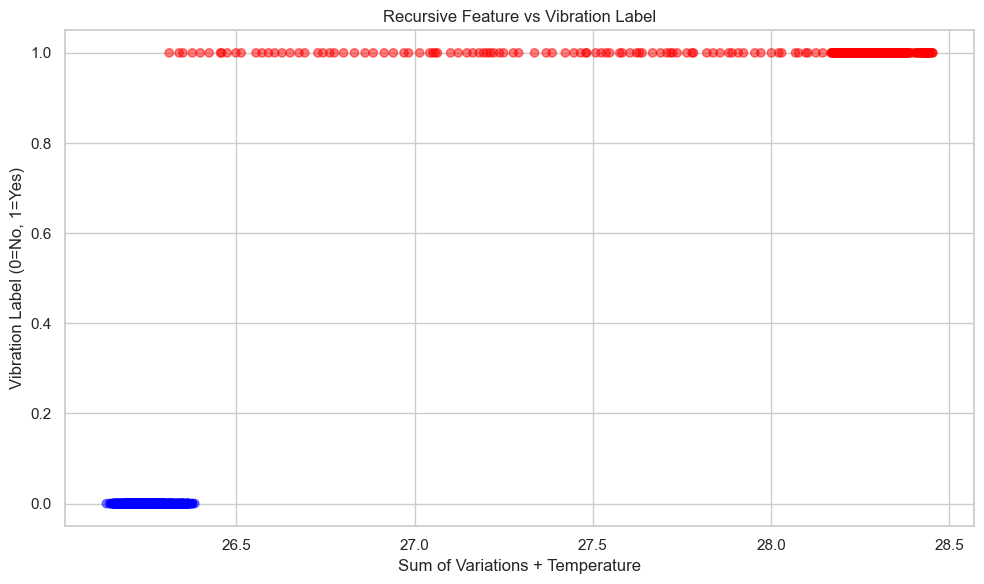

In [56]:
plt.figure(figsize=(10, 6))
colors = ['blue' if v == 0 else 'red' for v in vibration_labels]

plt.scatter(composite_variation, vibration_labels, c=colors, alpha=0.5)
plt.xlabel('Sum of Variations + Temperature')
plt.ylabel('Vibration Label (0=No, 1=Yes)')
plt.title('Recursive Feature vs Vibration Label')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation :
Increasing sum of variances + temperature strongly correlates with vibration detection.

So we need a Model that handle recursive/sequential data explicitly

### Save to CSV

In [62]:
csv_path = "robot_arm_mpu6050_dataset_realistic.csv"
df.to_csv(csv_path, index=False)

In [64]:
csv_path

'robot_arm_mpu6050_dataset_realistic.csv'